0.9896156073420838
1.0723639092552975
[0.01385887 0.02087714]
1.0301152936299651
1.010114980121483


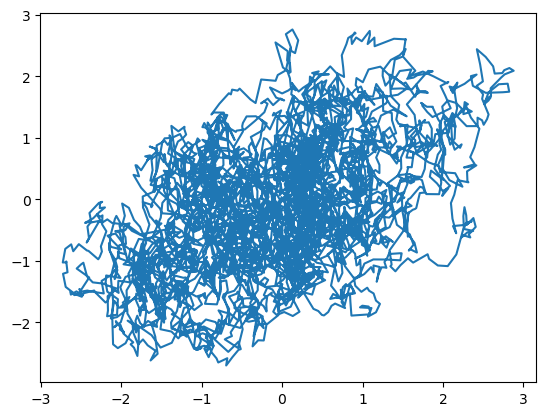

In [712]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from netCDF4 import Dataset as NetCDFFile
import pandas as pd
from scipy.linalg import logm, expm

G   = np.array([[0.9,0.1],[0,0.9]])
L   = logm(G)/10



x    = np.zeros((50000,2,1))
x[0,0,0] = np.random.normal(loc=0,scale=1)
x[0,1,0] = np.random.normal(loc=0,scale=1)
for i in range(50000):
    x[i,:,:]=G.dot(x[i-1,:,:])+np.reshape([np.random.normal(loc=0,scale=0.36),np.random.normal(loc=0,scale=0.43)],[2,1])

print(np.std(x[:,1]))  
print(np.std(x[:,0]))  
#print(np.std(x))  

C   = x[:,:,0].T.dot(x[:,:,0])/50000
#print(np.std(x[:,0,0]))
    
Q   = -(L.dot(C)+C.dot(L.T))
v,w = np.linalg.eig(Q)
    
print(v)
for i in range(1,50000):
    #noise = [np.random.normal(loc=0,scale=1),np.random.normal(loc=0,scale=1)]
    noise    = w.dot((v*0.1)**0.5)
    #noise    = noise*np.random.normal(loc=0,scale=1)
    noise[0] = noise[0]*np.random.normal(loc=0,scale=1)
    noise[1] = noise[1]*np.random.normal(loc=0,scale=1)
    x[i,:,0] = x[i-1,:,0]+L.dot(x[i-1,:,0])*0.1+noise

x_new    = np.zeros((5000,2,1))
for i in range(5000):
    x_new[i,:,:] = x[(i*10):(i+1)*10,:,:].mean(axis=0)
plt.plot(x_new[:,0,0],x_new[:,1,0])  
print(np.std(x_new[:,0]))
print(np.std(x_new[:,1]))

#np.std(x[:,0,0])
#np.std(x[:,1,0])
